# LSTM을 활용한 주가 예측 모델

이번 튜토리얼 에서는 다음과 같은 **프로세스 파이프라인**으로 주가 예측을 진행합니다.

- FinanceDataReader를 활용하여 주가 데이터 받아오기
- TensorFlow Dataset 클래스를 활용하여 주가 데이터 구축
- LSTM 을 활용한 주가 예측 모델 구축

## 필요한 모듈 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

%matplotlib inline
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'

## 데이터 (FinanceDataReader)

**FinanceDataReader**는 주가 데이터를 편리하게 가져올 수 있는 파이썬 패키지입니다.

- [GitHub Repo](https://github.com/FinanceData/FinanceDataReader)

**FinanceDataReader**가 아직 설치 되지 않으신 분들은 아래의 주석을 해제한 후 명령어로 설치해 주시기 바랍니다.

In [2]:
# !pip install finance-datareader

In [3]:
import FinanceDataReader as fdr

In [4]:
# 삼성전자(005930) 전체 (1996-11-05 ~ 현재)
samsung = fdr.DataReader('005930')

매우 편리하게 삼성전자 주가 데이터를 `DataFrame`형식으로 받아옵니다.

기본 **오름차순 정렬**이 된 데이터임을 알 수 있습니다.

### 컬럼 설명

- `Open`:   시가
- `High`:   고가
- `Low`:    저가
- `Close`:  종가
- `Volume`: 거래량
- `Change`: 대비

In [5]:
samsung.tail()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2024-09-09,66900,68200,66600,67500,23263298,-0.020319
2024-09-10,67000,67300,66000,66200,30651376,-0.019259
2024-09-11,65100,65500,64200,64900,35809707,-0.019637
2024-09-12,66000,66600,65200,66300,35884106,0.021572
2024-09-13,65000,65500,64300,64400,24842997,-0.028658


**미국 주식 데이터**도 가져올 수 있습니다.

In [6]:
# Apple(AAPL), 애플
apple = fdr.DataReader('AAPL')

In [7]:
apple.tail()

,Open,High,Low,Close,Volume,Adj Close
2024-09-12,222.500000,223.550003,219.820007,222.770004,37498200,222.770004
2024-09-13,223.580002,224.039993,221.910004,222.500000,36766600,222.500000
2024-09-16,216.539993,217.220001,213.919998,216.320007,59357400,216.320007
2024-09-17,215.750000,216.899994,214.500000,216.789993,45480900,216.789993
2024-09-18,217.589996,221.610001,217.539993,220.059998,20507798,220.059998


다음과 같이 `2017`을 같이 넘겨주면, 해당 시점 이후의 주식 데이터를 가져옵니다.

In [8]:
# Apple(AAPL), 애플
apple = fdr.DataReader('AAPL', '2017')

In [9]:
apple.head()

,Open,High,Low,Close,Volume,Adj Close
2017-01-03,28.950001,29.082500,28.690001,29.037500,115127600,26.921549
2017-01-04,28.962500,29.127501,28.937500,29.004999,84472400,26.891418
2017-01-05,28.980000,29.215000,28.952499,29.152500,88774400,27.028164
2017-01-06,29.195000,29.540001,29.117500,29.477501,127007600,27.329487
2017-01-09,29.487499,29.857500,29.485001,29.747499,134247600,27.579811


**시작**과 **끝** 날짜를 지정하여 범위 데이터를 가져올 수 있습니다.

In [10]:
# Ford(F), 1980-01-01 ~ 2019-12-30 (40년 데이터)
ford = fdr.DataReader('F', '1980-01-01', '2019-12-30')

In [11]:
ford.head()

,Open,High,Low,Close,Volume,Adj Close
1979-12-31,1.302678,1.307747,1.262127,1.297609,3916126,0.229297
1980-01-02,1.297609,1.328022,1.287471,1.287471,2044376,0.227506
1980-01-03,1.287471,1.287471,1.267196,1.287471,2816257,0.227506
1980-01-04,1.287471,1.287471,1.272265,1.277334,3038203,0.225714
1980-01-07,1.277334,1.287471,1.267196,1.267196,2251526,0.223923


In [12]:
ford.tail()

,Open,High,Low,Close,Volume,Adj Close
2019-12-20,9.50,9.54,9.44,9.48,50191200,7.699969
2019-12-23,9.50,9.57,9.40,9.44,54784400,7.667478
2019-12-24,9.44,9.49,9.43,9.47,11881600,7.691845
2019-12-26,9.47,9.49,9.43,9.45,28961300,7.675602
2019-12-27,9.45,9.46,9.35,9.36,28272800,7.602499


그 밖에 **금, 은과 같은 현물**, **달러와 같은 화폐** 데이터도 가져올 수 있습니다.

더욱 자세한 내용은 [GitHub 페이지 링크](https://github.com/FinanceData/FinanceDataReader)를 참고해 보시기 바랍니다.

In [13]:
## 주가데이터 가져오기

지난 주식 예측 튜토리얼에서는 **삼성전자** 주가데이터로 실습을 해봤으니,

이번에는 글로벌 증시의 대장주인 **Apple**사의 주가데이터를 가져와서 예측해 보도록 하겠습니다.

In [14]:
# 삼성전자 주식코드: 005930
STOCK_CODE = '005930'

In [15]:
stock = fdr.DataReader(STOCK_CODE)

In [16]:
stock.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2000-05-30,5600,5800,5520,5800,1299038,NaN
2000-05-31,6000,6290,5960,6160,1678705,0.062069
2000-06-01,6200,6410,6120,6300,1004689,0.022727
2000-06-02,6690,6899,6510,6620,1687778,0.050794
2000-06-05,6920,6980,6680,6740,960247,0.018127


In [17]:
stock.tail()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2024-09-09,66900,68200,66600,67500,23263298,-0.020319
2024-09-10,67000,67300,66000,66200,30651376,-0.019259
2024-09-11,65100,65500,64200,64900,35809707,-0.019637
2024-09-12,66000,66600,65200,66300,35884106,0.021572
2024-09-13,65000,65500,64300,64400,24842997,-0.028658


In [18]:
stock.index

DatetimeIndex(['2000-05-30', '2000-05-31', '2000-06-01', '2000-06-02',
               '2000-06-05', '2000-06-07', '2000-06-08', '2000-06-09',
               '2000-06-12', '2000-06-13',
               ...
               '2024-09-02', '2024-09-03', '2024-09-04', '2024-09-05',
               '2024-09-06', '2024-09-09', '2024-09-10', '2024-09-11',
               '2024-09-12', '2024-09-13'],
              dtype='datetime64[ns]', name='Date', length=6000, freq=None)

위에서 보시는 바와 같이 index가 `DatetimeIndex`로 지정되어 있습니다.

`DatetimeIndex`로 정의되어 있다면, 아래와 같이 연도, 월, 일을 쪼갤 수 있으며, **월별, 연도별 피벗데이터**를 만들때 유용하게 활용할 수 있습니다.

In [19]:
stock['Year'] = stock.index.year
stock['Month'] = stock.index.month
stock['Day'] = stock.index.day

In [20]:
stock.head()

,Open,High,Low,Close,Volume,Change,Year,Month,Day
Date,,,,,,,,,
2000-05-30,5600,5800,5520,5800,1299038,NaN,2000,5,30
2000-05-31,6000,6290,5960,6160,1678705,0.062069,2000,5,31
2000-06-01,6200,6410,6120,6300,1004689,0.022727,2000,6,1
2000-06-02,6690,6899,6510,6620,1687778,0.050794,2000,6,2
2000-06-05,6920,6980,6680,6740,960247,0.018127,2000,6,5


## 시각화

Text(0, 0.5, 'price')

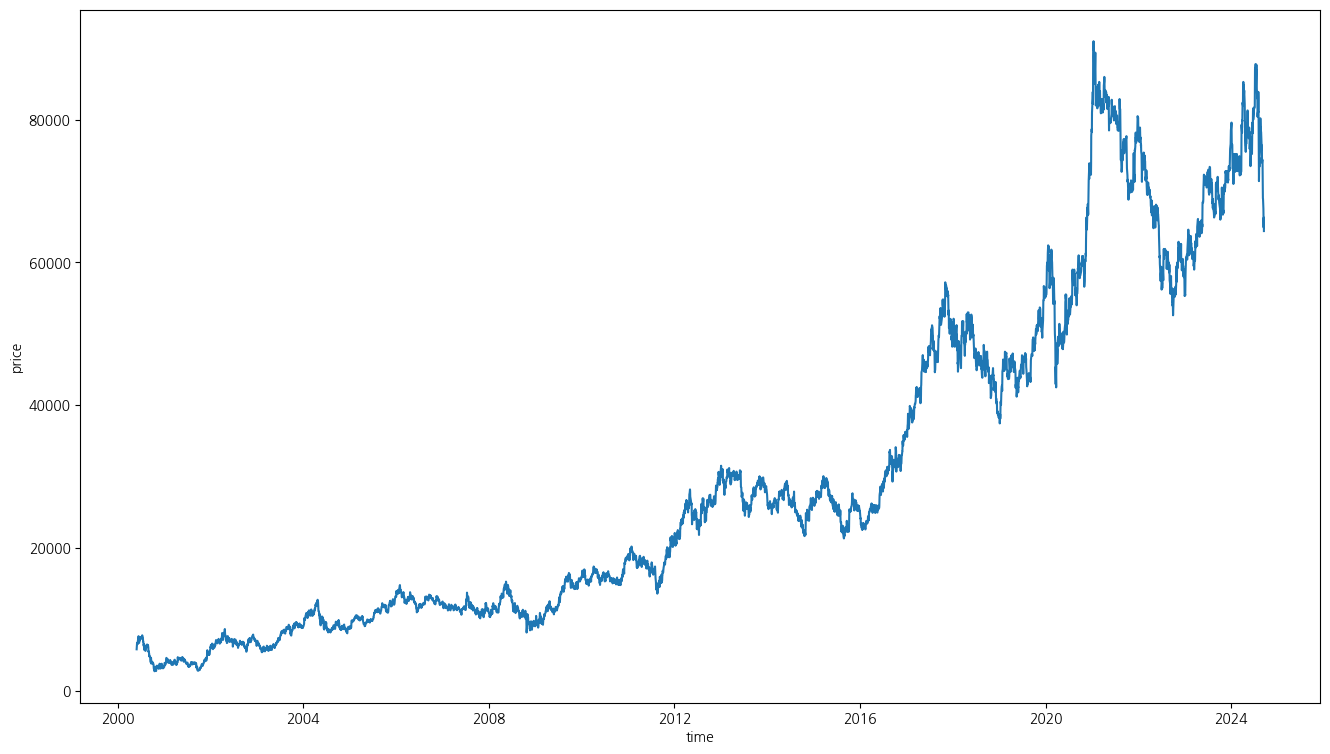

In [21]:
plt.figure(figsize=(16, 9))
sns.lineplot(y=stock['Close'], x=stock.index)
plt.xlabel('time')
plt.ylabel('price')

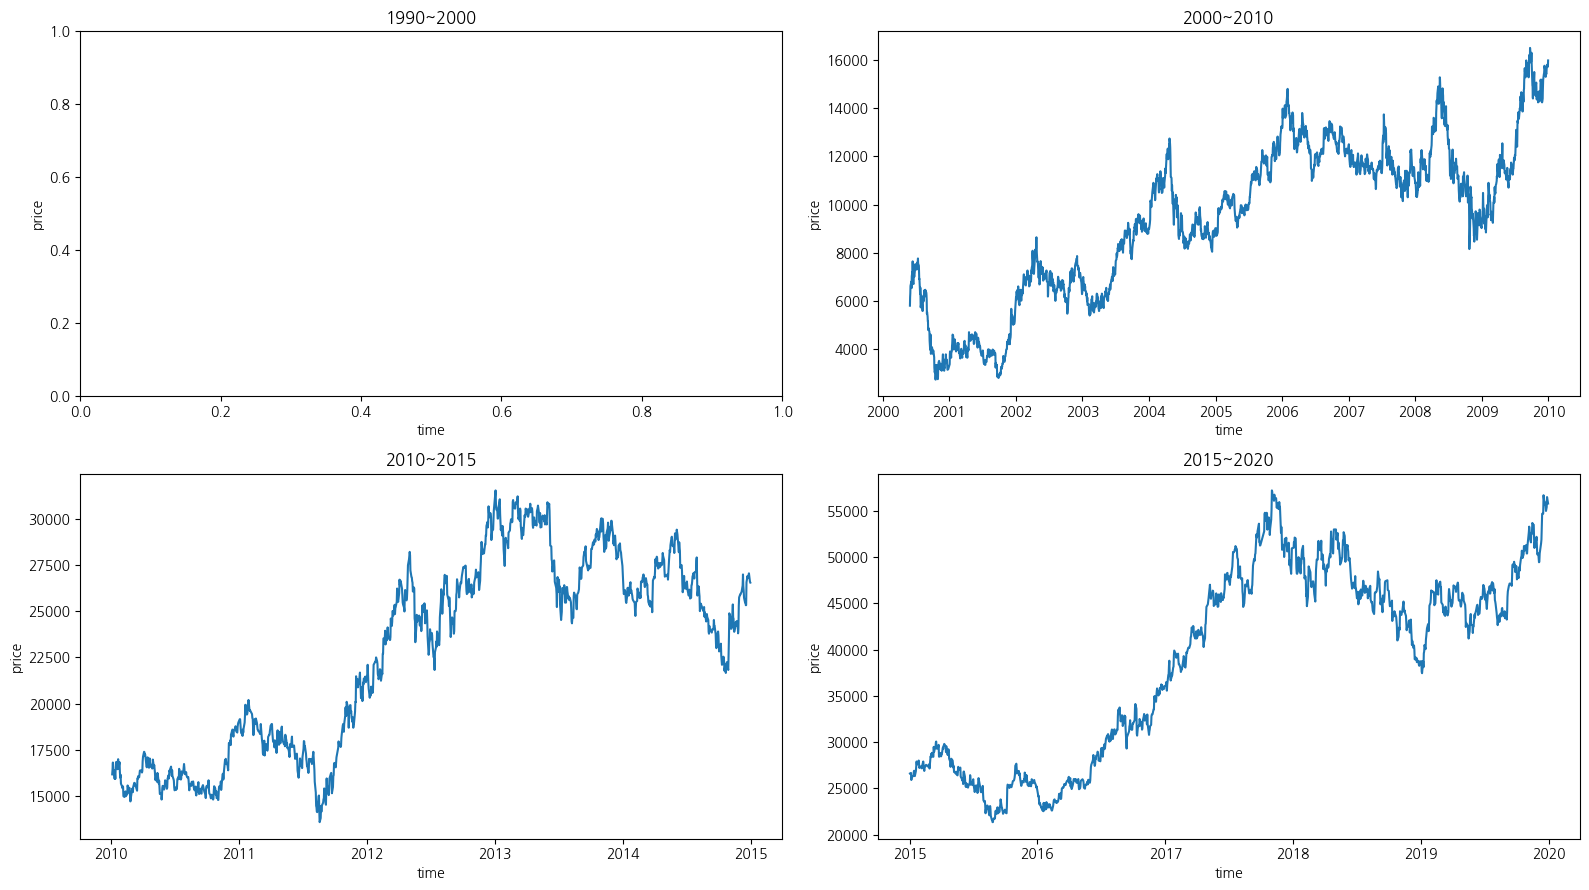

In [22]:
time_steps = [['1990', '2000'],
              ['2000', '2010'],
              ['2010', '2015'],
              ['2015', '2020']]

fig, axes = plt.subplots(2, 2)
fig.set_size_inches(16, 9)
for i in range(4):
    ax = axes[i//2, i%2]
    df = stock.loc[(stock.index > time_steps[i][0]) & (stock.index < time_steps[i][1])]
    sns.lineplot(y=df['Close'], x=df.index, ax=ax)
    ax.set_title(f'{time_steps[i][0]}~{time_steps[i][1]}')
    ax.set_xlabel('time')
    ax.set_ylabel('price')
plt.tight_layout()
plt.show()

## 데이터 전처리

주가 데이터에 대하여 딥러닝 모델이 더 잘 학습할 수 있도록 **정규화(Normalization)**를 해주도록 하겠습니다.

**표준화 (Standardization)**와 **정규화(Normalization)**에 대한 내용은 아래 링크에서 더 자세히 다루니, 참고해 보시기 바랍니다.

- [데이터 전처리에 관하여](https://teddylee777.github.io/scikit-learn/scikit-learn-preprocessing)

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# 스케일을 적용할 column을 정의합니다.
scale_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
# 스케일 후 columns
scaled = scaler.fit_transform(stock[scale_cols])
scaled

array([[0.0620155 , 0.05991736, 0.06167598, 0.03477965, 0.01438482],
       [0.06644518, 0.06497934, 0.06659218, 0.03885805, 0.01858904],
       [0.06866002, 0.06621901, 0.06837989, 0.04044409, 0.01112536],
       ...,
       [0.72093023, 0.67665289, 0.71731844, 0.7043163 , 0.39653663],
       [0.73089701, 0.68801653, 0.72849162, 0.72017673, 0.39736048],
       [0.71982281, 0.67665289, 0.71843575, 0.69865186, 0.27509743]])

스케일이 완료된 column으로 새로운 데이터프레임을 생성합니다.

**시간 순으로 정렬**되어 있으며, datetime index는 제외했습니다.

*6,000개의 row, 5개 column*으로 이루어진 데이터셋이 DataFrame으로 정리되었습니다.

In [24]:
df = pd.DataFrame(scaled, columns=scale_cols)

## train / test 분할

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Close', axis=1), df['Close'], test_size=0.2, random_state=0, shuffle=False)

In [28]:
x_train.shape, y_train.shape

((4800, 4), (4800,))

In [29]:
x_test.shape, y_test.shape

((1200, 4), (1200,))

In [31]:
x_train

,Open,High,Low,Volume
0,0.062016,0.059917,0.061676,0.014385
1,0.066445,0.064979,0.066592,0.018589
2,0.068660,0.066219,0.068380,0.011125
3,0.074086,0.071271,0.072737,0.018690
4,0.076633,0.072107,0.074637,0.010633
...,...,...,...,...
4795,0.561462,0.524793,0.560894,0.099212
4796,0.564784,0.530992,0.562011,0.114109
4797,0.560354,0.528926,0.563128,0.093768
4798,0.572536,0.540289,0.574302,0.144092


## TensroFlow Dataset을 활용한 시퀀스 데이터셋 구성

In [32]:
import tensorflow as tf

In [33]:
def windowed_dataset(series, window_size, batch_size, shuffle):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.map(lambda w: (w[:-1], w[-1]))
    return ds.batch(batch_size).prefetch(1)

Hyperparameter를 정의합니다.

In [34]:
WINDOW_SIZE=20
BATCH_SIZE=32

In [35]:
# trian_data는 학습용 데이터셋, test_data는 검증용 데이터셋 입니다.
train_data = windowed_dataset(y_train, WINDOW_SIZE, BATCH_SIZE, True)
test_data = windowed_dataset(y_test, WINDOW_SIZE, BATCH_SIZE, False)

In [36]:
# 아래의 코드로 데이터셋의 구성을 확인해 볼 수 있습니다.
# X: (batch_size, window_size, feature)
# Y: (batch_size, feature)
for data in train_data.take(1):
    print(f'데이터셋(X) 구성(batch_size, window_size, feature갯수): {data[0].shape}')
    print(f'데이터셋(Y) 구성(batch_size, window_size, feature갯수): {data[1].shape}')

데이터셋(X) 구성(batch_size, window_size, feature갯수): (32, 20, 1)
데이터셋(Y) 구성(batch_size, window_size, feature갯수): (32, 1)


## 모델

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Lambda
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model = Sequential([
    # 1차원 feature map 생성
    Conv1D(filters=32, kernel_size=5,
           padding="causal",
           activation="relu",
           input_shape=[WINDOW_SIZE, 1]),
    # LSTM
    LSTM(16, activation='tanh'),
    Dense(16, activation="relu"),
    Dense(1),
])

In [38]:
# Sequence 학습에 비교적 좋은 퍼포먼스를 내는 Huber()를 사용합니다.
loss = Huber()
optimizer = Adam(0.0005)
model.compile(loss=Huber(), optimizer=optimizer, metrics=['mse'])

In [40]:
import os
from keras.callbacks import EarlyStopping, ModelCheckpoint

# earlystopping은 10번 epoch통안 val_loss 개선이 없다면 학습을 멈춥니다.
earlystopping = EarlyStopping(monitor='val_loss', patience=10)

# val_loss 기준 체크포인터도 생성합니다.
filename = os.path.join('tmp', 'checkpointer.weights.h5')
checkpoint = ModelCheckpoint(filename,
                             save_weights_only=True,
                             save_best_only=True,
                             monitor='val_loss',
                             verbose=1)

In [41]:
history = model.fit(train_data,
                    validation_data=(test_data),
                    epochs=50,
                    callbacks=[checkpoint, earlystopping])

Epoch 1/50
    140/Unknown 2s 4ms/step - loss: 2.3901e-04 - mse: 4.7803e-04
Epoch 1: val_loss improved from inf to 0.00197, saving model to tmp\checkpointer.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3047e-04 - mse: 4.6093e-04 - val_loss: 0.0020 - val_mse: 0.0039
Epoch 2/50
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4365e-05 - mse: 4.8730e-05
Epoch 2: val_loss improved from 0.00197 to 0.00163, saving model to tmp\checkpointer.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4794e-05 - mse: 4.9589e-05 - val_loss: 0.0016 - val_mse: 0.0033
Epoch 3/50
144/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0642e-05 - mse: 4.1284e-05
Epoch 3: val_loss improved from 0.00163 to 0.00142, saving model to tmp\checkpointer.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1615e-05 - mse: 4.3229e-05 - val_loss: 0.0014 - val_mse: 0.0028
Epoch 4/50
142/150 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9319e-05 - mse: 3.8638e-05
Epoch 4: val_loss did not im

저장한 ModelCheckpoint 를 로드합니다.

In [42]:
model.load_weights(filename)

`test_data`를 활용하여 예측을 진행합니다.

In [43]:
pred = model.predict(test_data)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [44]:
pred.shape

(1180, 1)

## 예측 데이터 시각화

아래 시각화 코드중 y_test 데이터에 **[20:]**으로 슬라이싱을 한 이유는

예측 데이터에서 20일치의 데이터로 21일치를 예측해야하기 때문에 test_data로 예측 시 *앞의 20일은 예측하지 않습니다.*

따라서, 20번 째 index와 비교하면 더욱 정확합니다.

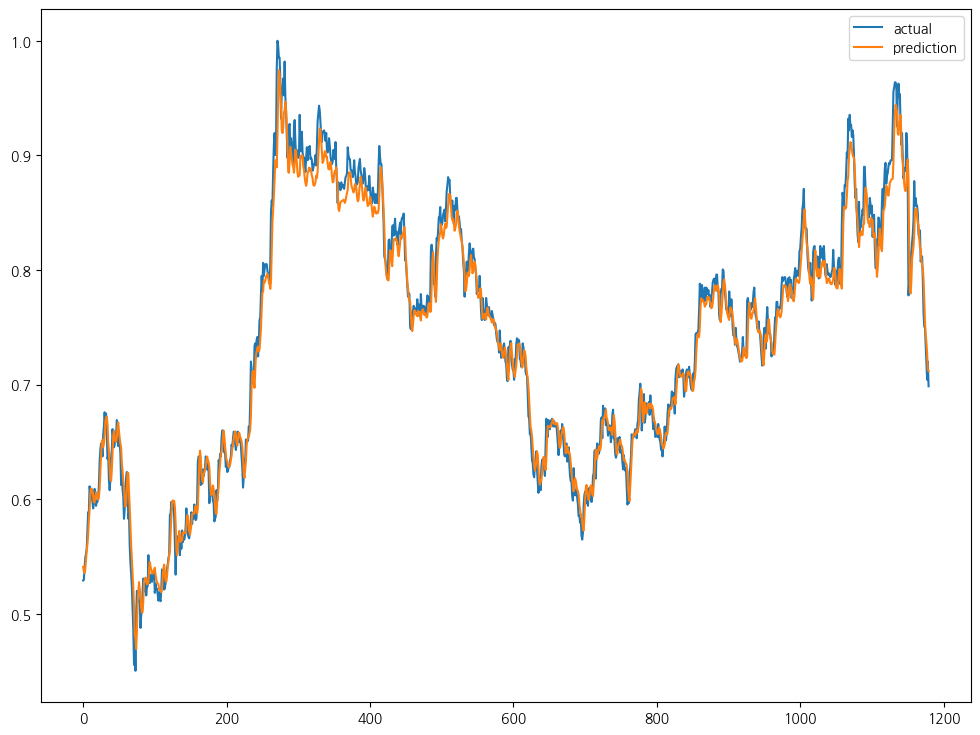

In [45]:
plt.figure(figsize=(12, 9))
plt.plot(np.asarray(y_test)[20:], label='actual')
plt.plot(pred, label='prediction')
plt.legend()
plt.show()